# Get Started with Anomalib v1.0

## 1. Anomalib via API

In [1]:
from anomalib.data import MVTec
from anomalib.models import Patchcore
from anomalib.engine import Engine

datamodule = MVTec(root="./datasets/MVTec", category="transistor", image_size=(224, 224))
model = Patchcore(input_size=(224, 224))
engine = Engine(image_metrics="AUROC", pixel_metrics="F1Score")

# Train the model
engine.train(model=model, datamodule=datamodule)

FeatureExtractor is deprecated. Use TimmFeatureExtractor instead. Both FeatureExtractor and TimmFeatureExtractor will be removed in a future release.
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/sakcay/.pyenv/versions/3.11.6/envs/anomalib_v1/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:36: UserWarning: Metric `PrecisionRecallCurve` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you shoul

Training: |          | 0/? [00:00<?, ?it/s]

/home/sakcay/.pyenv/versions/3.11.6/envs/anomalib_v1/lib/python3.11/site-packages/lightning/pytorch/loops/optimization/automatic.py:129: `training_step` returned `None`. If this was on purpose, ignore this warning...


Validation: |          | 0/? [00:00<?, ?it/s]

Output()

`Trainer.fit` stopped: `max_epochs=1` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │    0.9962499737739563     │
│       pixel_F1Score       │    0.6261693239212036     │
└───────────────────────────┴───────────────────────────┘

In [2]:
engine.export(model=model, datamodule=datamodule, input_size=(224, 224), export_mode="openvino")

/home/sakcay/Projects/anomalib/src/anomalib/models/image/patchcore/torch_model.py:224: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  n_neighbors=min(self.num_neighbors, memory_bank_effective_size),
/home/sakcay/.pyenv/versions/3.11.6/envs/anomalib_v1/lib/python3.11/site-packages/torch/onnx/symbolic_opset9.py:5856: UserWarning: Exporting aten::index operator of advanced indexing in opset 11 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(
/home/sakcay/.pyenv/versions/3.11.6/envs/anomalib_v1/lib/python3.11/site-packages/torch/onnx/_internal/jit_utils.py:307: UserWarning: Constant folding - Only steps=1 can be cons

In [3]:
from anomalib.deploy import OpenVINOInferencer

inferencer = OpenVINOInferencer(
    path="./weights/openvino/model.bin",
    metadata="./weights/openvino/metadata.json",
    device="CPU",
)

predictions = inferencer.predict(image="./datasets/MVTec/transistor/test/bent_lead/000.png")

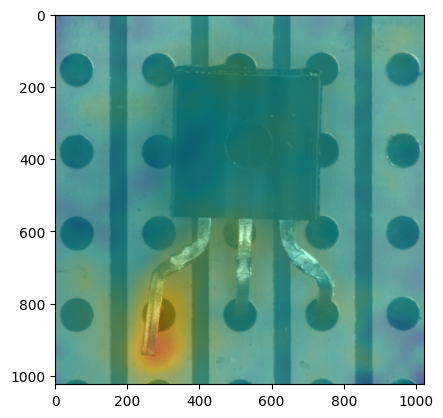

In [4]:
from matplotlib import pyplot as plt

plt.imshow(predictions.heat_map)

## Anomalib via CLI

In [5]:
!anomalib train --model anomalib.models.Patchcore --data anomalib.data.MVTec --data.category transistor

Seed set to 4047925753
2023-12-12 09:03:42,808 - anomalib.utils.config - WARNING - Anomalib currently does not support multi-gpu training. Setting devices to 1.
[12/12/23 09:03:42] WARNING  Anomalib currently does not support   ]8;id=277261;file:///home/sakcay/Projects/anomalib/src/anomalib/utils/config.py\config.py]8;;\:]8;id=833658;file:///home/sakcay/Projects/anomalib/src/anomalib/utils/config.py#239\239]8;;\
                             multi-gpu training. Setting devices                
                             to 1.                                              
[12/12/23 09:03:42] WARNING  Anomalib currently does not support   ]8;id=125427;file:///home/sakcay/Projects/anomalib/src/anomalib/utils/config.py\config.py]8;;\:]8;id=114128;file:///home/sakcay/Projects/anomalib/src/anomalib/utils/config.py#239\239]8;;\
                             multi-gpu training. Setting devices                
                             to 1.                                    

In [7]:
# Anomalib CLI with a config file
! anomalib fit --model Padim --data MVTec --print_config > config.yaml

In [8]:
! anomalib train -c config.yaml

Seed set to 2848616969
2023-12-12 09:11:05,880 - anomalib.utils.config - WARNING - Anomalib currently does not support multi-gpu training. Setting devices to 1.
[12/12/23 09:11:05] WARNING  Anomalib currently does not support   ]8;id=10631;file:///home/sakcay/Projects/anomalib/src/anomalib/utils/config.py\config.py]8;;\:]8;id=508597;file:///home/sakcay/Projects/anomalib/src/anomalib/utils/config.py#239\239]8;;\
                             multi-gpu training. Setting devices                
                             to 1.                                              
[12/12/23 09:11:05] WARNING  Anomalib currently does not support   ]8;id=700666;file:///home/sakcay/Projects/anomalib/src/anomalib/utils/config.py\config.py]8;;\:]8;id=246906;file:///home/sakcay/Projects/anomalib/src/anomalib/utils/config.py#239\239]8;;\
                             multi-gpu training. Setting devices                
                             to 1.                                     

## OTX 2.0 API

In [ ]:
from otx.data import COCO
from otx.models import DinoV2
from otx.engine import Engine
# or
form otx.trainer import Trainer


datamodule = COCO(...)
model = DinoV2(...)
engine = Engine(..)

engine.train()